
SIMPLE LINEAR REGRESSION
MSE : 61.11074662070013
RMSE: 7.817336286785936
R2  : 0.835796514007374

SLR P VALUE
Overall model p-value: 0.0
Previous Scores p-value: 0.0

MULTIPLE LINEAR REGRESSION
MSE : 4.305900938538477
RMSE: 2.0750664901488043
R2  : 0.9884301209927054

MLR P VALUES
Overall model p-value (F-test): 0.0
Intercept p-value = 0.0
Hours Studied p-value = 0.0
Previous Scores p-value = 0.0
Extracurricular Activities p-value = 1.3702426021997118e-35
Sleep Hours p-value = 1.7377705900262157e-249
Sample Question Papers Practiced p-value = 1.2243143912188164e-118


/tmp/ipython-input-403/3696890884.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Previous Scores p-value:", model_simple_sm.pvalues[1])


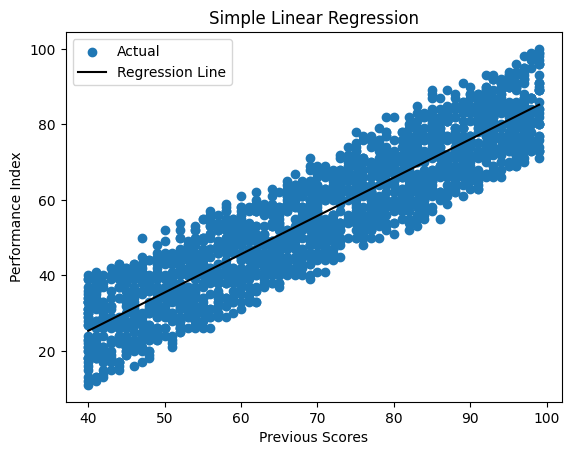

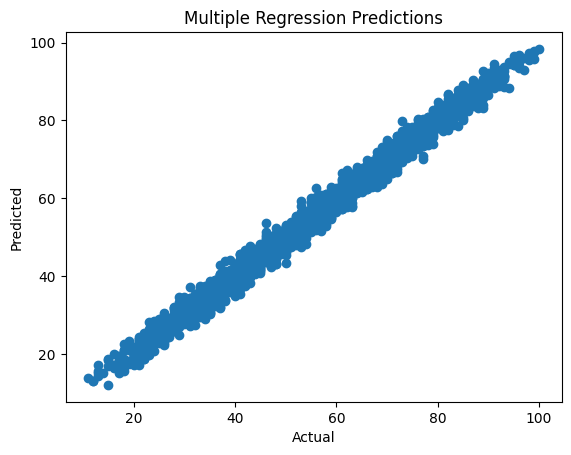

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

df = pd.read_csv("/content/Student_Performance.csv")

df = df.drop_duplicates()

df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes":1, "No":0})

X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

simple_feature = ["Previous Scores"]

X_train_simple = scaler.fit_transform(X_train[simple_feature])
X_test_simple = scaler.transform(X_test[simple_feature])

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

y_pred_simple = simple_model.predict(X_test_simple)

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("\nSIMPLE LINEAR REGRESSION")
print("MSE :", mse_simple)
print("RMSE:", rmse_simple)
print("R2  :", r2_simple)

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

y_pred_multi = multi_model.predict(X_test_scaled)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

X_train_simple_sm = sm.add_constant(X_train_simple)
model_simple_sm = sm.OLS(y_train, X_train_simple_sm).fit()

print("\nSLR P VALUE")
print("Overall model p-value:", model_simple_sm.f_pvalue)
print("Previous Scores p-value:", model_simple_sm.pvalues[1])


print("\nMULTIPLE LINEAR REGRESSION")
print("MSE :", mse_multi)
print("RMSE:", rmse_multi)
print("R2  :", r2_multi)

X_train_sm = sm.add_constant(X_train_scaled)
model_sm = sm.OLS(y_train, X_train_sm).fit()

print("\nMLR P VALUES")

print("Overall model p-value (F-test):", model_sm.f_pvalue)

for name, pval in zip(["Intercept"] + list(X.columns), model_sm.pvalues):
    print(f"{name} p-value = {pval}")

plt.figure()

plt.scatter(X_test[simple_feature], y_test, label="Actual")

sorted_idx = np.argsort(X_test[simple_feature].values.flatten())
X_sorted = X_test[simple_feature].values.flatten()[sorted_idx]
y_sorted = y_pred_simple[sorted_idx]

plt.plot(X_sorted, y_sorted, color="black", label="Regression Line")

plt.title("Simple Linear Regression")
plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")
plt.legend()
plt.show()


plt.figure()
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression Predictions")


plt.show()